# 04 — Root Cause Analysis

**RouteIQ — Delivery Operations Analytics**

**Business question:** Where does SLA breach *volume* concentrate, and
which area/traffic/weather combinations are associated with the most
breaches? ("If we could only fix a few things, which ones matter most?" —
`KPI_DEFINITIONS.md` #7, Delay Root-Cause Share.)

**Data used:** `data/cleaned/cleaned_delivery.csv` (43,648 rows), read-only.

**Analysis performed:** reuses `pareto_ranking()` from
`python/analysis/03_correlation_and_pareto.py` directly — the same ranking
that produced the approved `output/pareto_ranking.csv` and was
cross-validated against `sql/analysis/Q14`/`Q20`. This notebook reads that
function fresh; it does not overwrite the approved CSV.


In [1]:
from _nb_theme import setup_paths, apply_theme, NAVY, TEAL, CORAL, NEUTRAL_SEQUENCE, annotate_bars, sample_size_caption
project_root = setup_paths()
apply_theme()

import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from _common import load_cleaned_data

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
df = load_cleaned_data()
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from data/cleaned/cleaned_delivery.csv")


2026-08-17 14:27:49 | INFO     | routeiq_phase4 | Logging initialized. Log file: C:\Data Analyst Projects\RouteIQ Project\logs\phase1_pipeline_20260817_142749.log


2026-08-17 14:27:49 | INFO     | routeiq_phase4 | Loaded approved cleaned dataset: 43648 rows, 30 columns


Loaded 43,648 rows, 30 columns from data/cleaned/cleaned_delivery.csv


In [2]:
m3 = importlib.import_module("03_correlation_and_pareto")
pareto_df = m3.pareto_ranking(df)
print(f"{len(pareto_df)} rows across 3 dimensions: {pareto_df['dimension'].unique().tolist()}")


44 rows across 3 dimensions: ['area', 'category', 'weather_traffic']

## 1. Breach-Volume Concentration by Area

**Analysis performed:** the `area` cut of `pareto_ranking()`.


In [3]:
area_pareto = pareto_df[pareto_df["dimension"] == "area"].reset_index(drop=True)
area_pareto


,dimension,segment,n,breach_count,breach_rank,cumulative_breach_share_pct
0,area,Metropolitian,32634,8648,1,83.7335
1,area,Urban,9726,1398,2,97.2696
2,area,Semi-Urban,152,152,3,98.7413
3,area,Other,1136,130,4,100.0000


**Key observation:** Metropolitian alone accounts for **83.7335%** of all
SLA breach volume (8,648 of 10,328 total breaches) — but it also carries
74.8% of total delivery volume (32,634 of 43,648 rows), so its high breach
*share* partly reflects high delivery *volume*, not purely an elevated
rate (its rate, 26.50%, is well below Semi-Urban's 100% — see notebook 03).
Urban adds another 13.5 points to reach 97.2696% cumulative; Semi-Urban and
`Other` together make up the remaining ~2.7%.

**Limitation:** This is a volume-concentration ranking, not a root-cause
proof — it identifies *where* effort would touch the most breach volume,
not *why* those breaches happen.


## 2. Area × Traffic Breach Concentration (Pareto)

**Business question:** Which specific area/traffic combinations concentrate
the most SLA breach volume?

**Analysis performed:** reproduces the same Area×Traffic grouping as
`06_visualizations.py`'s `chart_pareto_area_traffic()` (rendered here with
the RouteIQ theme, inline, rather than written to `output/figures/`).


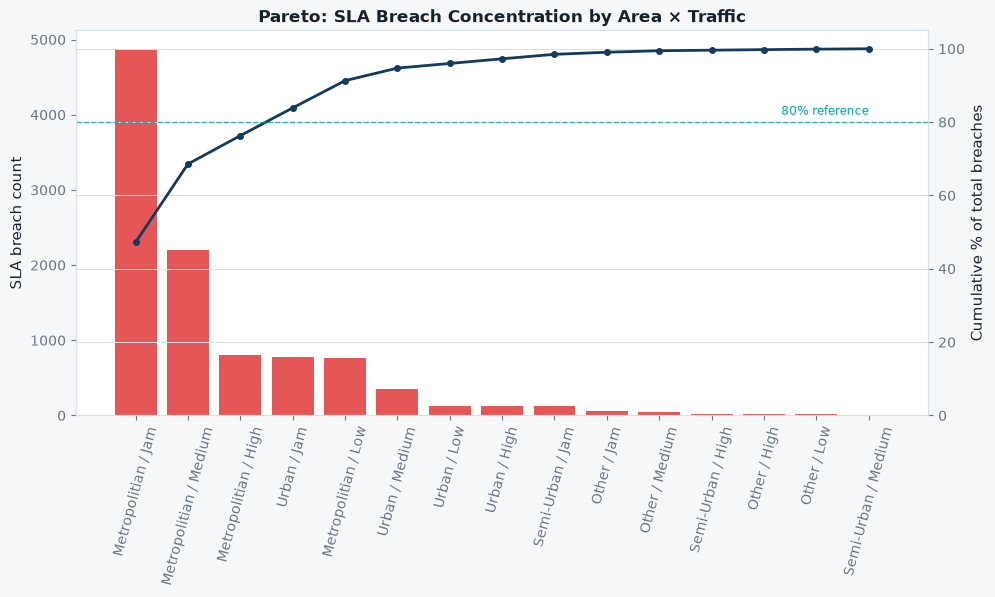

,Area,Traffic,breach_count,segment,cumulative_pct
0,Metropolitian,Jam,4877,Metropolitian / Jam,47.2211
1,Metropolitian,Medium,2205,Metropolitian / Medium,68.5709
2,Metropolitian,High,799,Metropolitian / High,76.3071
3,Urban,Jam,782,Urban / Jam,83.8788
4,Metropolitian,Low,767,Metropolitian / Low,91.3052
5,Urban,Medium,354,Urban / Medium,94.7328


In [4]:
at = (df.groupby(["Area", "Traffic"], observed=True)["sla_breach_flag"]
        .sum().sort_values(ascending=False).reset_index())
at.columns = ["Area", "Traffic", "breach_count"]
at["segment"] = at["Area"] + " / " + at["Traffic"]
at["cumulative_pct"] = 100 * at["breach_count"].cumsum() / at["breach_count"].sum()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(at["segment"], at["breach_count"], color=CORAL)
ax1.set_ylabel("SLA breach count")
ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(at["segment"], at["cumulative_pct"], color=NAVY, marker="o", markersize=4, linewidth=2)
ax2.axhline(80, color=TEAL, linestyle="--", linewidth=1, alpha=0.8)
ax2.text(len(at) - 1, 82, "80% reference", color=TEAL, fontsize=8.5, ha="right")
ax2.set_ylabel("Cumulative % of total breaches")
ax2.set_ylim(0, 105)
ax1.set_title("Pareto: SLA Breach Concentration by Area × Traffic")
ax1.grid(False)
plt.show()
at.head(6)


**Key observation:** The single Metropolitian/Jam combination is the
largest contributor of any area×traffic cut, and the top few combinations
cross the 80% reference line well before the full 15 observed combinations
are exhausted — consistent with Recommendation 1/2's evidence in
`docs/EXECUTIVE_RECOMMENDATIONS.md` (Jam-traffic periods, Metropolitian
specifically, as the highest-priority triage condition).

**Limitation:** Descriptive concentration ranking; no interaction-effect
test was run between Area and Traffic (out of the documented test plan
scope) — this shows where volume concentrates, not a statistically tested
interaction.


## 3. SLA Breach Rate by Traffic and by Weather

**Business question:** Which traffic and weather conditions are associated
with the highest breach *rate* (as opposed to raw *volume*, above)?


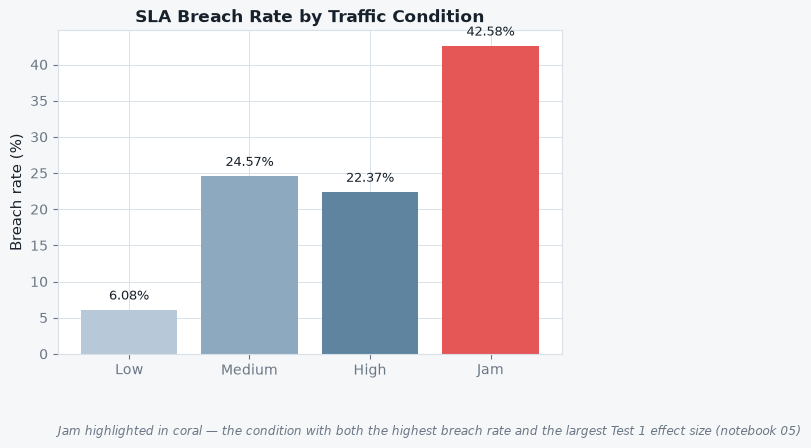

,n,breach_rate
Traffic,,
Low,14999,6.0804
Medium,10628,24.5672
High,4296,22.3696
Jam,13725,42.5792


In [5]:
by_traffic_breach = (df.groupby("Traffic", observed=True)["sla_breach_flag"]
                        .agg(n="count", breach_rate=lambda s: 100 * s.mean())
                        .reindex(["Low", "Medium", "High", "Jam"]))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
colors = [NEUTRAL_SEQUENCE[4], NEUTRAL_SEQUENCE[3], NEUTRAL_SEQUENCE[2], CORAL]
bars = ax.bar(by_traffic_breach.index, by_traffic_breach["breach_rate"], color=colors)
annotate_bars(ax, bars, fmt="{:.2f}%", offset=1)
ax.set_title("SLA Breach Rate by Traffic Condition")
ax.set_ylabel("Breach rate (%)")
sample_size_caption(ax, "Jam highlighted in coral — the condition with both the highest breach rate and the largest Test 1 effect size (notebook 05)")
plt.show()
by_traffic_breach


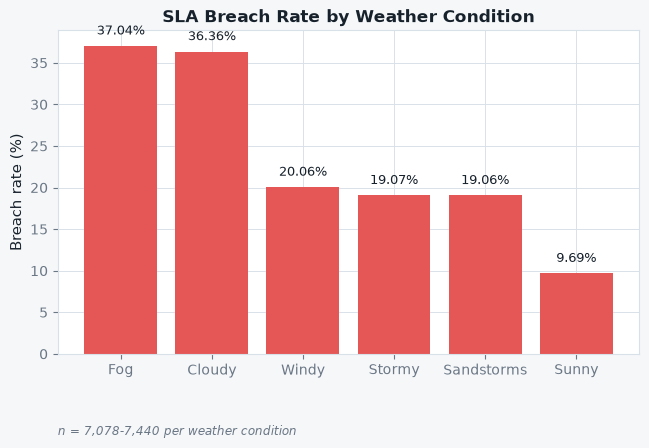

,n,breach_rate
Weather,,
Fog,7440,37.0430
Cloudy,7288,36.3611
Windy,7223,20.0609
Stormy,7374,19.0670
Sandstorms,7245,19.0614
Sunny,7078,9.6920


In [6]:
by_weather_breach = (df.groupby("Weather", observed=True)["sla_breach_flag"]
                        .agg(n="count", breach_rate=lambda s: 100 * s.mean())
                        .sort_values("breach_rate", ascending=False))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(by_weather_breach.index, by_weather_breach["breach_rate"], color=CORAL)
annotate_bars(ax, bars, fmt="{:.2f}%", offset=1)
ax.set_title("SLA Breach Rate by Weather Condition")
ax.set_ylabel("Breach rate (%)")
sample_size_caption(ax, "n = 7,078-7,440 per weather condition")
plt.show()
by_weather_breach


**Key observation:** Jam traffic has the highest breach rate by a wide
margin (42.58%, vs. 6-25% for the other three levels) — consistent with
Traffic being the strongest observed association with delivery time overall
(notebook 05, Test 1, ε²=0.1404, large effect). Fog and Cloudy weather have
the highest breach rates (~36-37%); Sunny the lowest (~9.7%) — consistent
with Weather's significant-but-small effect (Test 2, ε²=0.0517).

**Limitation:** Rate-based, descriptive. Statistical significance and
effect size for both factors are formally established in
`05_statistical_analysis.ipynb`, not here — this notebook shows the pattern
those tests explain.


## 4. Weather × Traffic — Largest Single Combination

**Analysis performed:** the `weather_traffic` cut of `pareto_ranking()`
(same function as §1, different dimension).


In [7]:
wt_pareto = pareto_df[pareto_df["dimension"] == "weather_traffic"].reset_index(drop=True)
wt_pareto.head(5)


,dimension,segment,n,breach_count,breach_rank,cumulative_breach_share_pct
0,weather_traffic,Fog / Jam,2365,1592,1,15.4144
1,weather_traffic,Cloudy / Jam,2267,1491,2,29.8509
2,weather_traffic,Windy / Jam,2286,855,3,38.1294
3,weather_traffic,Sandstorms / Jam,2316,814,4,46.0108
4,weather_traffic,Stormy / Jam,2259,799,5,53.7471


**Key observation:** Fog/Jam is the single largest weather×traffic breach
segment (15.41% of all breach volume on its own); the top 5 Jam-traffic
combinations together account for 53.75% of all breaches — reinforcing Jam
traffic as the dominant condition across every cut examined in this
notebook.

**Limitation:** Concentration evidence, not a tested interaction effect —
same caveat as §2.

---

**Next:** [`05_statistical_analysis.ipynb`](05_statistical_analysis.ipynb) —
the formal hypothesis tests behind every "associated with" claim in this
and the prior notebooks.
